# SIOC 251 - Homework 3 Monte Carlo Scattering

**Name:** Myles Jacobs

**Date:** 5/20/26

## Part 2: Non-Isotropic Scattering

### 6.1: Model Construction

### Derivation of $\cos\Theta$ for the Henyey-Greenstein Phase Function

To sample the scattering angle from a uniform distribution, we must first find the cumulative distribution function (CDF), $C(\cos\Theta)$, and then invert it. 

According to the assignment, the Henyey-Greenstein phase function is:
$$P_{HG}(\cos\Theta)=\frac{1-g^{2}}{(1+g^{2}-2g\cos\Theta)^{3/2}}$$

And the CDF is defined as:
$$C(\cos\Theta)=\frac{1}{2}\int_{-1}^{\cos\Theta}P_{HG}(x)dx$$

Substitute the phase function into the CDF integral, using $x$ as the dummy variable for $\cos\Theta$:
$$C(\cos\Theta) = \frac{1}{2} \int_{-1}^{\cos\Theta} \frac{1-g^2}{(1+g^2-2gx)^{3/2}} dx$$

To solve this integral, apply u-substitution. Let:
$$u = 1 + g^2 - 2gx$$
$$du = -2g \, dx \implies dx = -\frac{du}{2g}$$

Now, evaluate the integral boundaries:
* Lower bound ($x = -1$): $u = 1 + g^2 + 2g = (1+g)^2$
* Upper bound ($x = \cos\Theta$): $u = 1 + g^2 - 2g\cos\Theta$

Substitute these into the integral:
$$C(\cos\Theta) = \frac{1}{2} \int_{(1+g)^2}^{1+g^2-2g\cos\Theta} \frac{1-g^2}{u^{3/2}} \left(-\frac{du}{2g}\right)$$
$$C(\cos\Theta) = -\frac{1-g^2}{4g} \left[ \frac{u^{-1/2}}{-1/2} \right]_{(1+g)^2}^{1+g^2-2g\cos\Theta}$$
$$C(\cos\Theta) = \frac{1-g^2}{2g} \left[ \frac{1}{\sqrt{1+g^2-2g\cos\Theta}} - \frac{1}{\sqrt{(1+g)^2}} \right]$$
$$C(\cos\Theta) = \frac{1-g^2}{2g\sqrt{1+g^2-2g\cos\Theta}} - \frac{1-g}{2g}$$

To find the scattering angle, we set the CDF equal to a random number $\zeta$ drawn from a uniform distribution between $0$ and $1$, and solve for $\cos\Theta$:
$$\zeta = \frac{1-g^2}{2g\sqrt{1+g^2-2g\cos\Theta}} - \frac{1-g}{2g}$$

Isolate the square root term:
$$\zeta + \frac{1-g}{2g} = \frac{1-g^2}{2g\sqrt{1+g^2-2g\cos\Theta}}$$
$$\frac{2g\zeta + 1 - g}{2g} = \frac{1-g^2}{2g\sqrt{1+g^2-2g\cos\Theta}}$$
$$\frac{1-g+2g\zeta}{1-g^2} = \frac{1}{\sqrt{1+g^2-2g\cos\Theta}}$$

Invert both sides and square them:
$$\sqrt{1+g^2-2g\cos\Theta} = \frac{1-g^2}{1-g+2g\zeta}$$
$$1+g^2-2g\cos\Theta = \left(\frac{1-g^2}{1-g+2g\zeta}\right)^2$$

Finally, solve for $\cos\Theta$:
$$2g\cos\Theta = 1+g^2 - \left(\frac{1-g^2}{1-g+2g\zeta}\right)^2$$
$$\cos\Theta = \frac{1}{2g} \left( 1+g^2 - \left(\frac{1-g^2}{1-g+2g\zeta}\right)^2 \right)$$

*(Note: If $g=0$, this equation is undefined, and the code must fall back to the isotropic scattering solution: $\cos\Theta = 2\zeta - 1$)*

In [13]:
import os

# Create the figures directory if it does not already exist
figures_dir = 'figures'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Created directory: {figures_dir}/")
else:
    print(f"Directory {figures_dir}/ already exists.")

Created directory: figures/


In [2]:
import numpy as np

def run_monte_carlo_hg_scattering(num_photons, tau_star, omega, g, theta_deg, z_atm=1.0):
    """
    Simulates radiative transfer with non-isotropic (Henyey-Greenstein) scattering.
    
    Parameters:
    - num_photons: Number of photons entering the atmosphere.
    - tau_star: Total optical depth of the atmosphere.
    - omega: Single scatter albedo (probability of scattering vs absorption).
    - g: Asymmetry parameter (-1 to 1). 0 is isotropic, >0 is forward, <0 is backward.
    - theta_deg: Solar zenith angle in degrees.
    - z_atm: Geometric thickness of the atmosphere.
    
    Returns:
    - A dictionary containing albedo, direct/diffuse/total transmittance, and absorptance.
    """
    if theta_deg >= 90.0:
        return {"albedo": 1.0, "total_transmittance": 0.0, "absorptance": 0.0}

    # Initial incoming angles
    theta_rad = np.radians(theta_deg)
    phi_rad = 0.0 # Arbitrary incoming azimuth

    # 1. Initialize photon directions and positions
    # kz is negative because photons enter traveling downward towards the surface
    kx = np.sin(theta_rad) * np.cos(phi_rad) * np.ones(num_photons)
    ky = np.sin(theta_rad) * np.sin(phi_rad) * np.ones(num_photons)
    kz = -np.cos(theta_rad) * np.ones(num_photons) 
    
    # All photons start at the top of the atmosphere
    z = np.full(num_photons, z_atm)

    # Tracking arrays
    active = np.ones(num_photons, dtype=bool)
    scatters = np.zeros(num_photons, dtype=int)

    # Outcome arrays
    reflected = np.zeros(num_photons, dtype=bool)
    transmitted = np.zeros(num_photons, dtype=bool)
    absorbed = np.zeros(num_photons, dtype=bool)

    # Mean free path in geometric units
    mfp = z_atm / tau_star

    # Loop until all photons have either exited or been absorbed
    while np.any(active):
        N_active = np.sum(active)

        # Step 1: Calculate the sampled optical depth traveled by each active photon
        zeta = np.random.uniform(0, 1, N_active)
        L = -mfp * np.log(1 - zeta)

        # Step 2: Move photons along their current trajectory
        z[active] += L * kz[active]

        # Step 3: Check boundaries to see if photons hit the ground or exited the top
        hit_ground = z <= 0
        hit_top = z >= z_atm

        just_transmitted = active & hit_ground
        just_reflected = active & hit_top

        transmitted[just_transmitted] = True
        reflected[just_reflected] = True

        # Deactivate photons that have exited the atmosphere
        active[just_transmitted | just_reflected] = False

        # Step 4: Process interactions for photons still inside the atmosphere
        interacting = active.copy()
        N_int = np.sum(interacting)
        if N_int == 0:
            break

        # Step 5: Determine Scattering vs Absorption
        zeta_omega = np.random.uniform(0, 1, N_int)
        is_scatter = zeta_omega < omega

        # Handle Absorption
        is_absorbed = ~is_scatter
        absorbed_global = np.zeros(num_photons, dtype=bool)
        absorbed_global[interacting] = is_absorbed
        
        absorbed[absorbed_global] = True
        active[absorbed_global] = False # Deactivate absorbed photons

        # Handle Scattering
        scatter_global = np.zeros(num_photons, dtype=bool)
        scatter_global[interacting] = is_scatter
        scatters[scatter_global] += 1

        N_scat = np.sum(scatter_global)
        if N_scat > 0:
            # Step 6: Generate Non-Isotropic Scattering Angles (Henyey-Greenstein)
            u = np.random.uniform(0, 1, N_scat)
            
            if g == 0.0:
                # Isotropic case fallback
                cos_Theta = 2 * u - 1
            else:
                # Henyey-Greenstein inverse CDF
                term = (1 - g**2) / (1 - g + 2 * g * u)
                cos_Theta = (1 + g**2 - term**2) / (2 * g)
                
            sin_Theta = np.sqrt(np.maximum(0, 1 - cos_Theta**2)) # maximum used to prevent floating point domain errors
            
            # Uniform in Phi (0 to 2*pi)
            Phi = np.random.uniform(0, 2 * np.pi, N_scat)

            # Scattered direction in the photon's local coordinate system
            kp_x = sin_Theta * np.cos(Phi)
            kp_y = sin_Theta * np.sin(Phi)
            kp_z = cos_Theta

            # Step 7: Coordinate Rotation (Appendix A)
            kx_s = kx[scatter_global]
            ky_s = ky[scatter_global]
            kz_s = kz[scatter_global]

            # Z_p axis (incoming direction)
            zp_x, zp_y, zp_z = kx_s, ky_s, kz_s

            # X_p axis
            norm_xy = np.sqrt(kx_s**2 + ky_s**2)
            xp_x = np.zeros_like(kx_s)
            xp_y = np.zeros_like(ky_s)
            xp_z = np.zeros_like(kz_s)

            # Handle the special case where photon is traveling exactly vertically
            vertical = norm_xy < 1e-8
            not_vertical = ~vertical

            if np.any(vertical):
                xp_x[vertical] = 1.0
                xp_y[vertical] = 0.0
                xp_z[vertical] = 0.0

            if np.any(not_vertical):
                xp_x[not_vertical] = -ky_s[not_vertical] / norm_xy[not_vertical]
                xp_y[not_vertical] = kx_s[not_vertical] / norm_xy[not_vertical]
                xp_z[not_vertical] = 0.0

            # Y_p axis = Z_p cross X_p
            yp_x = zp_y * xp_z - zp_z * xp_y
            yp_y = zp_z * xp_x - zp_x * xp_z
            yp_z = zp_x * xp_y - zp_y * xp_x

            # Rotate scattered vector into model coordinates
            knew_x = kp_x * xp_x + kp_y * yp_x + kp_z * zp_x
            knew_y = kp_x * xp_y + kp_y * yp_y + kp_z * zp_y
            knew_z = kp_x * xp_z + kp_y * yp_z + kp_z * zp_z

            # Normalize to avoid numerical drift over many scatters
            norm_knew = np.sqrt(knew_x**2 + knew_y**2 + knew_z**2)
            kx[scatter_global] = knew_x / norm_knew
            ky[scatter_global] = knew_y / norm_knew
            kz[scatter_global] = knew_z / norm_knew

    # Calculate final statistics
    direct = transmitted & (scatters == 0)
    diffuse = transmitted & (scatters > 0)

    return {
        "direct_transmittance": np.sum(direct) / num_photons,
        "diffuse_transmittance": np.sum(diffuse) / num_photons,
        "total_transmittance": np.sum(transmitted) / num_photons,
        "albedo": np.sum(reflected) / num_photons,
        "absorptance": np.sum(absorbed) / num_photons
    }

# --- Execution Example ---
# Simulating 100,000 photons, tau=1.0, omega=0.8, g=0.75 (strong forward scattering), solar zenith=0 deg
results = run_monte_carlo_hg_scattering(num_photons=100000, tau_star=1.0, omega=0.8, g=0.75, theta_deg=0.0)

print("--- Results ---")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance: {results['diffuse_transmittance']:.4f}")
print(f"Total Transmittance:   {results['total_transmittance']:.4f}")
print(f"Albedo (Reflected):    {results['albedo']:.4f}")
print(f"Absorptance:           {results['absorptance']:.4f}")
print(f"Total Sum (Check):     {sum([results['total_transmittance'], results['albedo'], results['absorptance']]):.4f}")

--- Results ---
Direct Transmittance:  0.3700
Diffuse Transmittance: 0.3802
Total Transmittance:   0.7502
Albedo (Reflected):    0.0403
Absorptance:           0.2095
Total Sum (Check):     1.0000


### 6.2 Verification

Let's test the limits of the asymmetry parameter:
+ g = 0 should fall back to the isotropic case
+ g $\rightarrow$ 1 means 100% of photons scatter forward
+ g $\rightarrow$ -1 means 100% of photons scatter backward

In [6]:
results = run_monte_carlo_hg_scattering(num_photons=100000, tau_star=1.0, omega=0.8, g=0.0, theta_deg=0.0)

print("--- Results For g=0 ---")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance: {results['diffuse_transmittance']:.4f}")
print(f"Total Transmittance:   {results['total_transmittance']:.4f}")
print(f"Albedo (Reflected):    {results['albedo']:.4f}")
print(f"Absorptance:           {results['absorptance']:.4f}")
print(f"Total Sum (Check):     {sum([results['total_transmittance'], results['albedo'], results['absorptance']]):.4f}")

--- Results For g=0 ---
Direct Transmittance:  0.3671
Diffuse Transmittance: 0.1726
Total Transmittance:   0.5397
Albedo (Reflected):    0.2126
Absorptance:           0.2477
Total Sum (Check):     1.0000


These results match almost exactly the isotropic results from part 5.1

In [7]:
results = run_monte_carlo_hg_scattering(num_photons=100000, tau_star=1.0, omega=0.8, g=1.0, theta_deg=0.0)

print("--- Results For g=1 ---")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance: {results['diffuse_transmittance']:.4f}")
print(f"Total Transmittance:   {results['total_transmittance']:.4f}")
print(f"Albedo (Reflected):    {results['albedo']:.4f}")
print(f"Absorptance:           {results['absorptance']:.4f}")
print(f"Total Sum (Check):     {sum([results['total_transmittance'], results['albedo'], results['absorptance']]):.4f}")

--- Results For g=1 ---
Direct Transmittance:  0.3680
Diffuse Transmittance: 0.4493
Total Transmittance:   0.8173
Albedo (Reflected):    0.0000
Absorptance:           0.1827
Total Sum (Check):     1.0000


Noticably, there is absolutely no albedo for the g=1.0 case, meaning this is working correctly

In [8]:
results = run_monte_carlo_hg_scattering(num_photons=100000, tau_star=1.0, omega=0.8, g=-1.0, theta_deg=0.0)

print("--- Results For g=1 ---")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance: {results['diffuse_transmittance']:.4f}")
print(f"Total Transmittance:   {results['total_transmittance']:.4f}")
print(f"Albedo (Reflected):    {results['albedo']:.4f}")
print(f"Absorptance:           {results['absorptance']:.4f}")
print(f"Total Sum (Check):     {sum([results['total_transmittance'], results['albedo'], results['absorptance']]):.4f}")

--- Results For g=1 ---
Direct Transmittance:  0.3684
Diffuse Transmittance: 0.0764
Total Transmittance:   0.4448
Albedo (Reflected):    0.3794
Absorptance:           0.1758
Total Sum (Check):     1.0000


The diffuse transmittance shrinks drastically, meaning the only photons that reach the surface are ones that did not scatter at all. The albedo is highest of all cases. This matches what we'd expect for g = -1.0

### 6.3a: Theoretical Derivation of Albedo for Optically Thin, Isotropic Scattering

**Question:** Using theory alone, show that for $\tau \ll 1$ and $g=0$, the albedo is $\alpha \approx \tau\tilde{\omega}/2$. You can assume that the solar zenith angle is $0^{\circ}$, so that $\mu_{0}=1$.

**Proof:**

1.  **Probability of Interaction:** For a photon traveling through an atmosphere with total optical depth $\tau$, the probability that it undergoes an interaction (either scattering or absorption) before reaching the surface is given by $1 - e^{-\tau/\mu_0}$. 
    
    Given the solar zenith angle is $0^{\circ}$, we have $\mu_0 = 1$. Since the atmosphere is optically thin ($\tau \ll 1$), we can approximate the exponential term using a first-order Taylor expansion ($e^{-x} \approx 1 - x$ for small $x$).
    $$1 - e^{-\tau} \approx 1 - (1 - \tau) = \tau$$
    Therefore, the fraction of incoming photons that interact with the atmosphere is approximately $\tau$.

2.  **Probability of Scattering:**
    Of the photons that interact, the fraction that scatter rather than being absorbed is defined by the single scattering albedo, $\tilde{\omega}$.
    
    Since we are in the optically thin regime ($\tau \ll 1$), we can assume that multiple scattering events are negligible (a photon interacts at most once). Thus, the total fraction of the original incoming photons that experience a scattering event is:
    $$\text{Fraction Scattered} \approx \tau\tilde{\omega}$$

3.  **Direction of Scattering (Isotropic):**
    The asymmetry parameter is given as $g=0$, which corresponds to perfectly isotropic scattering. In isotropic scattering, a photon is equally likely to be scattered in any direction over a full $4\pi$ steradian solid angle. 
    
    Consequently, exactly half of the scattered photons will be directed into the upward hemisphere (reflected back to space) and half will be directed into the downward hemisphere (transmitted to the surface). 

4.  **Calculating Albedo:**
    The albedo ($\alpha$) at the top of the atmosphere is defined as the fraction of total incoming photons that are reflected back to space. Based on the previous steps, this is simply half of the total scattered fraction:
    $$\alpha \approx \frac{1}{2} (\text{Fraction Scattered})$$
    $$\alpha \approx \frac{\tau\tilde{\omega}}{2}$$



In [10]:
# --- 6.3b: Model Verification of Optically Thin Albedo ---

# 1. Set parameters for the optically thin, isotropic case
num_photons = 1_000_000  # High number needed because scattering events are rare when tau << 1
tau_star = 0.01          # Optically thin (tau << 1)
omega = 0.8              # Single scatter albedo
g = 0.0                  # Isotropic scattering
theta_deg = 0.0          # Solar zenith angle = 0 (mu_0 = 1)

# 2. Calculate Theoretical Albedo
albedo_theoretical = (tau_star * omega) / 2.0

# 3. Run the Monte Carlo Model
results = run_monte_carlo_hg_scattering(
    num_photons=num_photons, 
    tau_star=tau_star, 
    omega=omega, 
    g=g, 
    theta_deg=theta_deg
)
albedo_model = results['albedo']

# 4. Compare the results
error_margin = abs(albedo_model - albedo_theoretical)
percent_error = (error_margin / albedo_theoretical) * 100

print("--- 6.3b: Model Verification of Optically Thin Albedo ---")
print(f"Parameters: tau={tau_star}, omega={omega}, g={g}, theta={theta_deg} deg")
print(f"Theoretical Albedo: {albedo_theoretical:.6f}")
print(f"Model Albedo:       {albedo_model:.6f}")
print(f"Absolute Error:     {error_margin:.6f}")
print(f"Percent Error:      {percent_error:.2f}%")

--- 6.3b: Model Verification of Optically Thin Albedo ---
Parameters: tau=0.01, omega=0.8, g=0.0, theta=0.0 deg
Theoretical Albedo: 0.004000
Model Albedo:       0.003905
Absolute Error:     0.000095
Percent Error:      2.38%


Running simulations across different values of g...


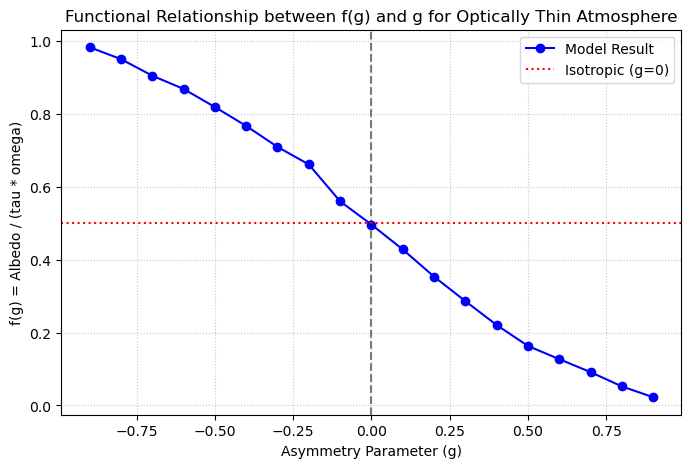

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 6.3c: Functional Relationship of f(g) ---

# 1. Set constant parameters for the optically thin case
num_photons = 500_000  # High photon count to minimize noise
tau_star = 0.01        # Optically thin (tau << 1)
omega = 1.0            # Representative value for single scatter albedo
theta_deg = 0.0        # Solar zenith angle = 0 (mu_0 = 1)

# 2. Define an array of g values to test (from strong backscatter to strong forward scatter)
g_values = np.linspace(-0.9, 0.9, 19)
f_g_model = []

print("Running simulations across different values of g...")

# 3. Loop through g values and run the model
for g in g_values:
    results = run_monte_carlo_hg_scattering(
        num_photons=num_photons, 
        tau_star=tau_star, 
        omega=omega, 
        g=g, 
        theta_deg=theta_deg
    )
    
    albedo = results['albedo']
    
    # Calculate f(g) = alpha / (tau * omega)
    f_g = albedo / (tau_star * omega)
    f_g_model.append(f_g)

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(g_values, f_g_model, 'o-', color='b', label='Model Result')
plt.axvline(0, color='k', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='r', linestyle=':', label='Isotropic (g=0)')

plt.xlabel('Asymmetry Parameter (g)')
plt.ylabel('f(g) = Albedo / (tau * omega)')
plt.title('Functional Relationship between f(g) and g for Optically Thin Atmosphere')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.savefig('figures/part2_6-3c_f_g_relationship.png', dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

+ Physical Meaning of $f(g)$: Since $\tau\tilde{\omega}$ represents the total fraction of photons that scatter in an optically thin atmosphere, dividing the albedo (upward scattered photons) by this value gives the fraction of scattered light that is directed back to space.
+ Isotropic Scattering ($g = 0$): As proven in 6.3a, when scattering is isotropic, exactly half of the scattered light goes up, and half goes down. The plot confirms that $f(0) \approx 0.5$.
+ Forward Scattering ($g > 0$): As $g$ approaches 1, the phase function becomes highly peaked in the forward direction. Most scattered photons continue traveling downward toward the surface, causing the albedo to drop. Therefore, $f(g)$ approaches $0$.
+ Backward Scattering ($g < 0$): As $g$ approaches -1, the phase function becomes highly peaked in the backward direction. Most scattered photons bounce directly back up and exit the top of the atmosphere, causing the albedo to rise. Therefore, $f(g)$ approaches $1$.

### Analytical Derivation of $B(g)$

The backscatter function represents the fraction of scattered light directed into the backward hemisphere. It is defined as:
$$B(g)=\frac{1}{2}\int_{-1}^{0}P_{HG}(\mu,g)d\mu$$

Substitute the Henyey-Greenstein phase function into the integral:
$$B(g) = \frac{1}{2} \int_{-1}^{0} \frac{1-g^2}{(1+g^2-2g\mu)^{3/2}} d\mu$$

To solve this, apply u-substitution. Let:
$$u = 1 + g^2 - 2g\mu$$
$$du = -2g \, d\mu \implies d\mu = -\frac{du}{2g}$$

Determine the new bounds of integration:
* Lower bound ($\mu = -1$): $u = 1 + g^2 + 2g = (1+g)^2$
* Upper bound ($\mu = 0$): $u = 1 + g^2$

Substitute $u$ and the new bounds into the integral:
$$B(g) = \frac{1}{2} \int_{(1+g)^2}^{1+g^2} \frac{1-g^2}{u^{3/2}} \left(-\frac{du}{2g}\right)$$
$$B(g) = -\frac{1-g^2}{4g} \int_{(1+g)^2}^{1+g^2} u^{-3/2} du$$

Evaluate the integral:
$$B(g) = -\frac{1-g^2}{4g} \left[ \frac{u^{-1/2}}{-1/2} \right]_{(1+g)^2}^{1+g^2}$$
$$B(g) = \frac{1-g^2}{2g} \left[ \frac{1}{\sqrt{1+g^2}} - \frac{1}{\sqrt{(1+g)^2}} \right]$$

Since $\sqrt{(1+g)^2} = 1+g$ (assuming $g > -1$), we can simplify the second term:
$$B(g) = \frac{1-g^2}{2g\sqrt{1+g^2}} - \frac{1-g^2}{2g(1+g)}$$

Factor $1-g^2$ as $(1-g)(1+g)$ in the second term to cancel the denominator:
$$B(g) = \frac{1-g^2}{2g\sqrt{1+g^2}} - \frac{1-g}{2g}$$

*(Note: For isotropic scattering where $g=0$, applying L'Hôpital's rule or integrating $P_{HG}(\mu, 0) = 1$ directly yields $B(0) = 0.5$)*

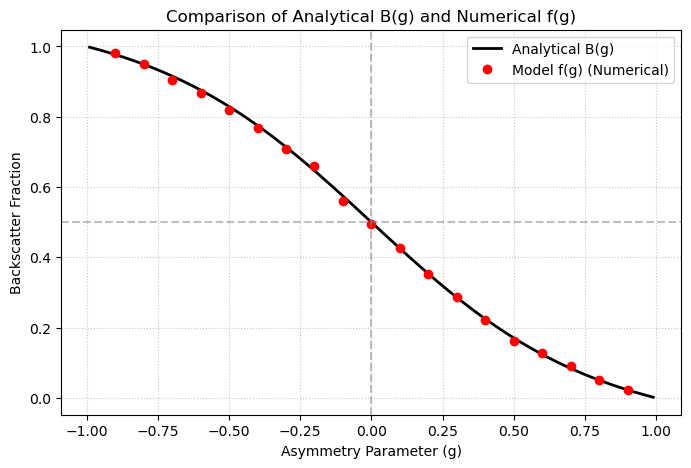

--- Comparison Check ---
    g |   Model f(g) | Analytical B(g) |     Diff
--------------------------------------------------
 -0.5 |       0.8186 |          0.8292 |   0.0106
  0.0 |       0.4962 |          0.5000 |   0.0038


In [15]:
# --- 6.3d: Comparing Analytical B(g) to Numerical f(g) ---

# 1. Define the analytical backscatter function B(g)
def analytical_Bg(g):
    """Calculates the theoretical backscatter fraction B(g) for the HG phase function."""
    # Handle the g=0 case to prevent division by zero
    if g == 0:
        return 0.5
    
    term1 = (1 - g**2) / (2 * g * np.sqrt(1 + g**2))
    term2 = (1 - g) / (2 * g)
    return term1 - term2

# Vectorize the function so it can handle numpy arrays
analytical_Bg_vec = np.vectorize(analytical_Bg)

# 2. Generate a smooth array of g values for the theoretical curve
g_smooth = np.linspace(-0.99, 0.99, 200)
Bg_theoretical = analytical_Bg_vec(g_smooth)

# 3. Plot the comparison
plt.figure(figsize=(8, 5))

# Plot the theoretical curve
plt.plot(g_smooth, Bg_theoretical, '-', color='k', linewidth=2, label='Analytical B(g)')

# Plot the numerical results from Part 6.3c
# (Assumes g_values and f_g_model are still in memory from the previous cell)
plt.plot(g_values, f_g_model, 'o', color='red', markersize=6, label='Model f(g) (Numerical)')

# Formatting the plot
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Asymmetry Parameter (g)')
plt.ylabel('Backscatter Fraction')
plt.title('Comparison of Analytical B(g) and Numerical f(g)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.savefig('figures/part2_6-3d_backscatter_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

# 4. Print numerical comparison for a few sample points
print("--- Comparison Check ---")
print(f"{'g':>5} | {'Model f(g)':>12} | {'Analytical B(g)':>15} | {'Diff':>8}")
print("-" * 50)
for g_val, fg_val in zip(g_values, f_g_model):
    if g_val in [-0.5, 0.0, 0.5]:  # Just sample a few key values for the table
        bg_val = analytical_Bg(g_val)
        diff = abs(fg_val - bg_val)
        print(f"{g_val:>5.1f} | {fg_val:>12.4f} | {bg_val:>15.4f} | {diff:>8.4f}")

### 6.3e - Student Investigation

**Question**:  Let's set the backscatter fraction to the approximation defined in class: $$B(g) = (1-g)/2$$ and create the same plot from part 6.3d. *Where on this plot does this approximation fail?* 

**Hypothesis**: The approximation should hold for the limits -1, 0, 1, and close to those values. It should very clearly be breaking down around -0.5 and 0.5.

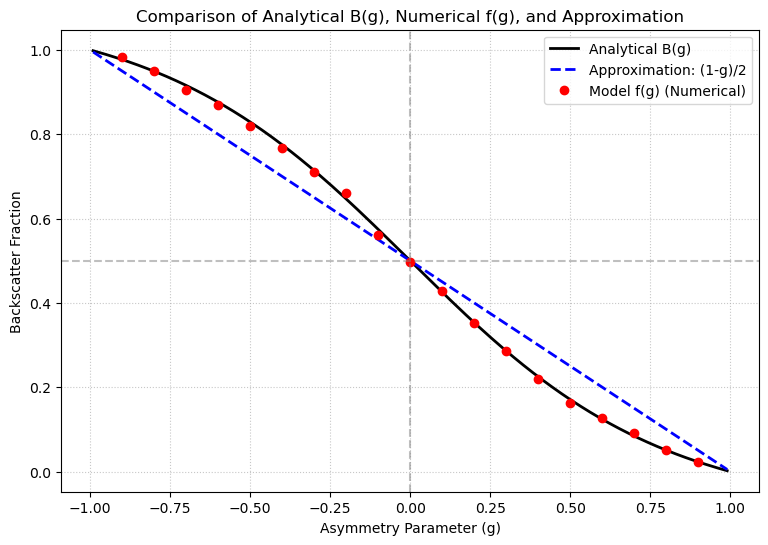

--- Comparison Check ---
    g |   Model f(g) | Analytical B(g) |  Approx (1-g)/2
-------------------------------------------------------
 -0.5 |       0.8186 |          0.8292 |          0.7500
  0.0 |       0.4962 |          0.5000 |          0.5000


In [16]:
# --- 6.3d: Comparing Analytical B(g), Numerical f(g), and Approximation ---

# 1. Define the analytical backscatter function B(g)
def analytical_Bg(g):
    """Calculates the theoretical backscatter fraction B(g) for the HG phase function."""
    if g == 0:
        return 0.5
    
    term1 = (1 - g**2) / (2 * g * np.sqrt(1 + g**2))
    term2 = (1 - g) / (2 * g)
    return term1 - term2

analytical_Bg_vec = np.vectorize(analytical_Bg)

# 2. Generate smooth arrays for the theoretical and approximation curves
g_smooth = np.linspace(-0.99, 0.99, 200)
Bg_theoretical = analytical_Bg_vec(g_smooth)

# Define the linear approximation from class
Bg_approx = (1 - g_smooth) / 2.0

# 3. Plot the comparison
plt.figure(figsize=(9, 6))

# Plot the theoretical curve
plt.plot(g_smooth, Bg_theoretical, '-', color='k', linewidth=2, label='Analytical B(g)')

# Plot the linear approximation
plt.plot(g_smooth, Bg_approx, '--', color='blue', linewidth=2, label='Approximation: (1-g)/2')

# Plot the numerical results from Part 6.3c
# (Assumes g_values and f_g_model are still in memory)
plt.plot(g_values, f_g_model, 'o', color='red', markersize=6, label='Model f(g) (Numerical)')

# Formatting the plot
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Asymmetry Parameter (g)')
plt.ylabel('Backscatter Fraction')
plt.title('Comparison of Analytical B(g), Numerical f(g), and Approximation')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Save the figure to the figures folder
plt.savefig('figures/part2_6-3d_backscatter_comparison_with_approx.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

# 4. Print numerical comparison table
print("--- Comparison Check ---")
print(f"{'g':>5} | {'Model f(g)':>12} | {'Analytical B(g)':>15} | {'Approx (1-g)/2':>15}")
print("-" * 55)
for g_val, fg_val in zip(g_values, f_g_model):
    if g_val in [-0.5, 0.0, 0.5]:  # Sample a few key values for the table
        bg_val = analytical_Bg(g_val)
        approx_val = (1 - g_val) / 2.0
        print(f"{g_val:>5.1f} | {fg_val:>12.4f} | {bg_val:>15.4f} | {approx_val:>15.4f}")

As predicted, the approximation from class is *good enough* for the extreme values (and very close thereto) but it very clearly fails for values -0.5 and 0.5 

### AI Usage

+ Tool Used: Gemini (Google)
+ How it was used: Gemini generated the bulk of the code of the original model, as well as the figures.
+ Parts checked independently: Model was verified at limiting cases by hand. (Section 6.2)
+ Markdown cell derivations done by hand.
  